# 1. Title
**Experiment No. 3**  
**Generative Adversarial Networks (GANs)**  
**Name:** Sachin Bhabad  
**PRN:** 202301040282

---
# 2. Aim
To implement a Deep Convolutional Generative Adversarial Network (DCGAN) on a chosen image dataset to generate original image data, providing a comprehensive summary of the architecture, training process, and evaluation of visual results. To present a case study analysis on real-world GAN applications and ethical considerations.

---
# 3. Dataset
- **Dataset Name:** CIFAR-10 (Canadian Institute For Advanced Research)
- **Brief Description:** A widely used benchmark dataset in computer vision containing natural color images.
- **Image Dimensions:** 32x32 pixels (3 channels - RGB)
- **Number of Classes/Images:** 10 distinct classes (e.g., airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck) with a total of 60,000 images.
- **Why it is suitable:** CIFAR-10 provides colorful, complex, and low-resolution object structures. It is computationally manageable for a laboratory setting but challenging enough to clearly demonstrate the generative capabilities and mode behavior of a DCGAN without requiring massive computational resources.

---
# 4. Theory
- **GAN Concept:** Introduced by Ian Goodfellow (2014), a GAN consists of two neural networks pitted against each other in a zero-sum game framework to generate new, synthetic instances of data that can pass for real data.
- **Generator (G):** Takes a vector of random noise (latent space) as input and outputs a synthetic image. Its goal is to fool the discriminator.
- **Discriminator (D):** Takes an image (either real from the dataset or fake from the generator) and outputs a probability of it being real. Its goal is to correctly classify real vs. fake.
- **Adversarial Training:** They are trained simultaneously. G learns to produce increasingly realistic images, while D learns to become better at detecting fakes. The ideal equilibrium is when G's outputs are indistinguishable from real data (D outputs 0.5 probability).
- **DCGAN Architecture:** A Deep Convolutional GAN replaces fully connected layers with Convolutional layers (using strided convolutions in D and fractional-strided convolutions in G), utilizes Batch Normalization, and specifically employs LeakyReLU for the Discriminator and ReLU/Tanh for the Generator to ensure stable training.


# 5. Data Preparation
Loading the CIFAR-10 dataset, normalizing the pixel values to the range `[-1, 1]` (as required by the Generator's `Tanh` activation function), and preparing the DataLoader.


Using Device: cuda


  0%|          | 0.00/170M [00:00<?, ?B/s]

  0%|          | 32.8k/170M [00:00<34:47, 81.7kB/s]

  0%|          | 98.3k/170M [00:00<15:29, 183kB/s] 

  0%|          | 229k/170M [00:00<08:20, 340kB/s] 

...

100%|█████████▉| 170M/170M [07:50<00:00, 312kB/s]

100%|█████████▉| 170M/170M [07:50<00:00, 365kB/s]

100%|█████████▉| 170M/170M [07:51<00:00, 422kB/s]

100%|█████████▉| 170M/170M [07:51<00:00, 374kB/s]

100%|██████████| 170M/170M [07:51<00:00, 362kB/s]

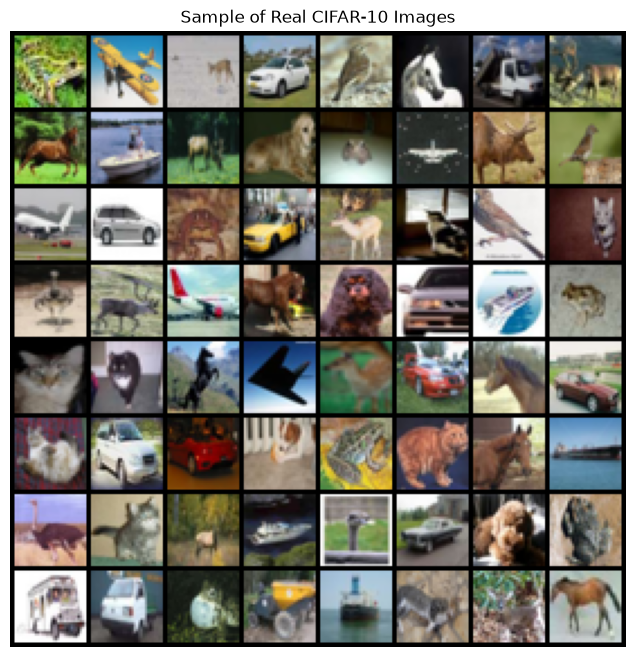

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
manualSeed = 42
np.random.seed(manualSeed)
torch.manual_seed(manualSeed)

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

# Hyperparameters
batch_size = 128
image_size = 32
workers = 2

# Data Preprocessing: Normalize to [-1, 1]
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load CIFAR-10
dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=workers)

# Display a batch of Real Images
real_batch = next(iter(dataloader))
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Sample of Real CIFAR-10 Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0][:64], padding=2, normalize=True).cpu(),(1,2,0)))
plt.show()


# 6. DCGAN Architecture
## Discriminator & Generator Definition
- **Latent Vector (Noise):** 100-dimensional normally distributed random vector.
- **Generator Architecture:** Uses `ConvTranspose2d` layers to upsample the latent vector to `32x32x3`. Uses `BatchNorm2d` and `ReLU`, with a final `Tanh` activation.
- **Discriminator Architecture:** Uses strided `Conv2d` layers to downsample the `32x32x3` image to a scalar probability. Uses `LeakyReLU(0.2)` and a final `Sigmoid` activation.
- **Loss Function:** Binary Cross Entropy Loss (`BCELoss`), suited for the binary classification nature of the Discriminator.
- **Optimizer:** Adam optimizer with learning rate `0.0002` and Beta1 `0.5` (standard established hyperparameter values for stable DCGAN training).


In [2]:
# Architecture hyperparameters
nz = 100 # Size of z latent vector (i.e. size of generator input)
ngf = 64 # Size of feature maps in generator
ndf = 64 # Size of feature maps in discriminator

# Custom weights initialization called on netG and netD
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# Generator
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # input is Z, going into a convolution
            nn.ConvTranspose2d(nz, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # state size. (ngf*4) x 4 x 4
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # state size. (ngf*2) x 8 x 8
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # state size. (ngf) x 16 x 16
            nn.ConvTranspose2d(ngf, 3, 4, 2, 1, bias=False),
            nn.Tanh()
            # state size. 3 x 32 x 32
        )

    def forward(self, input):
        return self.main(input)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # input is 3 x 32 x 32
            nn.Conv2d(3, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf) x 16 x 16
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*2) x 8 x 8
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*4) x 4 x 4
            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

# Instantiate models and apply initialization
netG = Generator().to(device)
netG.apply(weights_init)
print("Generator Architecture:\n", netG)

netD = Discriminator().to(device)
netD.apply(weights_init)
print("\nDiscriminator Architecture:\n", netD)


Generator Architecture:
 Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)

Discriminator Architecture:
 Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, in

# 7. Model Instantiation & 8. Model Training
Here we define the optimizers, the BCELoss criterion, and begin the adversarial training loop. We will train for 20 epochs.
Fixed noise is created prior to training so we can visually track the Generator's progress on the exact same latent inputs over time.


In [3]:
# Initialize BCELoss function
criterion = nn.BCELoss()

# Create fixed noise for visual progress tracking
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

# Establish convention for real and fake labels during training
real_label = 1.
fake_label = 0.

# Setup Adam optimizers
lr = 0.0002
beta1 = 0.5
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

# Training Loop
num_epochs = 20
G_losses = []
D_losses = []
img_list = []

print("Starting Training Loop...")
for epoch in range(num_epochs):
    for i, data in enumerate(dataloader, 0):

        # ----------------------------------------
        # (1) Update D network: maximize log(D(x)) + log(1 - D(G(z)))
        # ----------------------------------------
        netD.zero_grad()
        
        # Train with all-real batch
        real_cpu = data[0].to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
        
        output = netD(real_cpu).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        # Train with all-fake batch
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(fake_label)
        
        output = netD(fake.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        
        errD = errD_real + errD_fake
        optimizerD.step()

        # ----------------------------------------
        # (2) Update G network: maximize log(D(G(z)))
        # ----------------------------------------
        netG.zero_grad()
        label.fill_(real_label) # fake labels are real for generator cost
        output = netD(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()
        optimizerG.step()
        
        # Save Losses for plotting later
        G_losses.append(errG.item())
        D_losses.append(errD.item())

    # Print epoch metrics
    print(f'[{epoch+1}/{num_epochs}] Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f} D(x): {D_x:.4f} D(G(z)): {D_G_z1:.4f} / {D_G_z2:.4f}')
    
    # Save a fixed batch of generated images to track progress
    with torch.no_grad():
        fake = netG(fixed_noise).detach().cpu()
    img_list.append(vutils.make_grid(fake, padding=2, normalize=True))


Starting Training Loop...


[1/20] Loss_D: 0.2642 Loss_G: 5.2560 D(x): 0.8641 D(G(z)): 0.0766 / 0.0090


[2/20] Loss_D: 0.7362 Loss_G: 3.6760 D(x): 0.7156 D(G(z)): 0.2433 / 0.0491


[3/20] Loss_D: 0.6916 Loss_G: 4.9178 D(x): 0.9016 D(G(z)): 0.3977 / 0.0120


[4/20] Loss_D: 0.3948 Loss_G: 3.6142 D(x): 0.8681 D(G(z)): 0.1930 / 0.0407


...

[16/20] Loss_D: 0.7716 Loss_G: 2.5416 D(x): 0.8073 D(G(z)): 0.3908 / 0.1065


[17/20] Loss_D: 0.5511 Loss_G: 1.8183 D(x): 0.8384 D(G(z)): 0.2858 / 0.1955


[18/20] Loss_D: 0.6074 Loss_G: 1.8391 D(x): 0.6821 D(G(z)): 0.1666 / 0.1836


[19/20] Loss_D: 0.6456 Loss_G: 1.7902 D(x): 0.6555 D(G(z)): 0.1603 / 0.1990


[20/20] Loss_D: 0.7159 Loss_G: 1.9626 D(x): 0.7400 D(G(z)): 0.3079 / 0.1690


# 9. Generated Results
## 9.1 Loss Curves
Plotting the Generator and Discriminator loss over iterations to observe training stability.


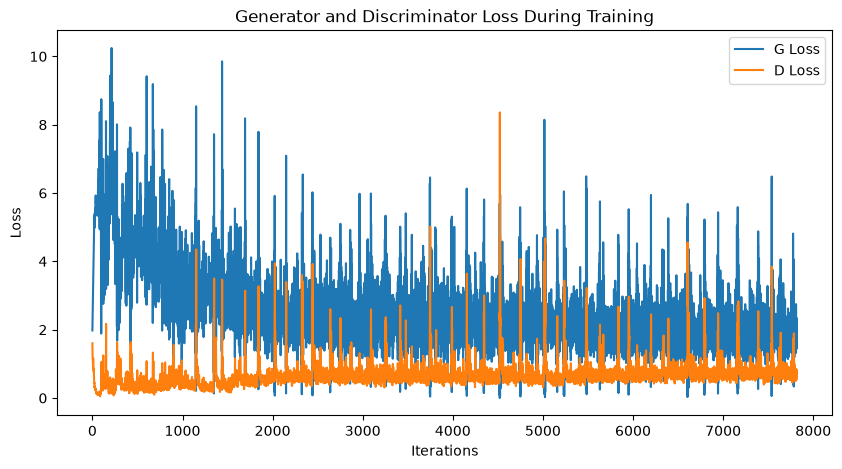

In [4]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G Loss")
plt.plot(D_losses, label="D Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()


## 9.2 Training Progression (Fixed Latent Space)
Tracking how the generated images evolved from pure noise at Epoch 1 to structured features by the final epoch.


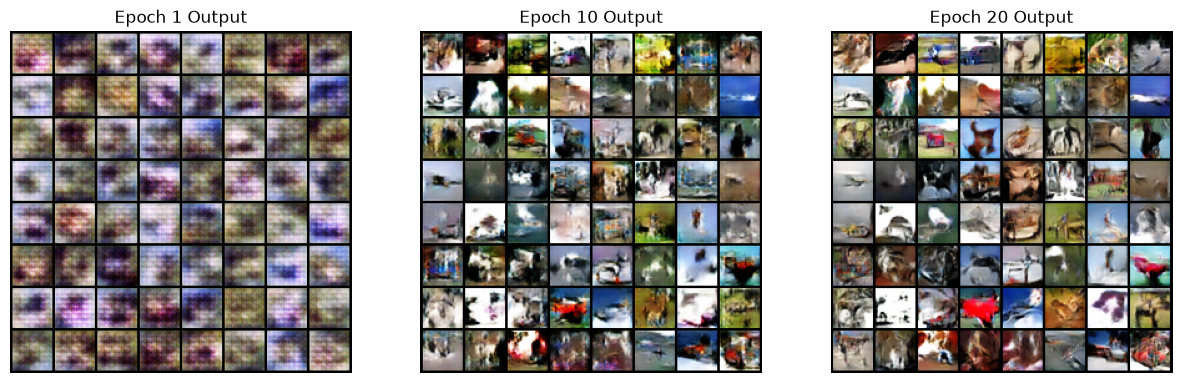

In [5]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.axis("off")
plt.title("Epoch 1 Output")
plt.imshow(np.transpose(img_list[0],(1,2,0)))

plt.subplot(1,3,2)
plt.axis("off")
plt.title(f"Epoch {num_epochs//2} Output")
plt.imshow(np.transpose(img_list[num_epochs//2 - 1],(1,2,0)))

plt.subplot(1,3,3)
plt.axis("off")
plt.title(f"Epoch {num_epochs} Output")
plt.imshow(np.transpose(img_list[-1],(1,2,0)))

plt.show()


## 9.3 Final Comparison: Real vs Fake Images
Comparing a batch of original CIFAR-10 datasets with a freshly generated batch of Fake Images from random noise.


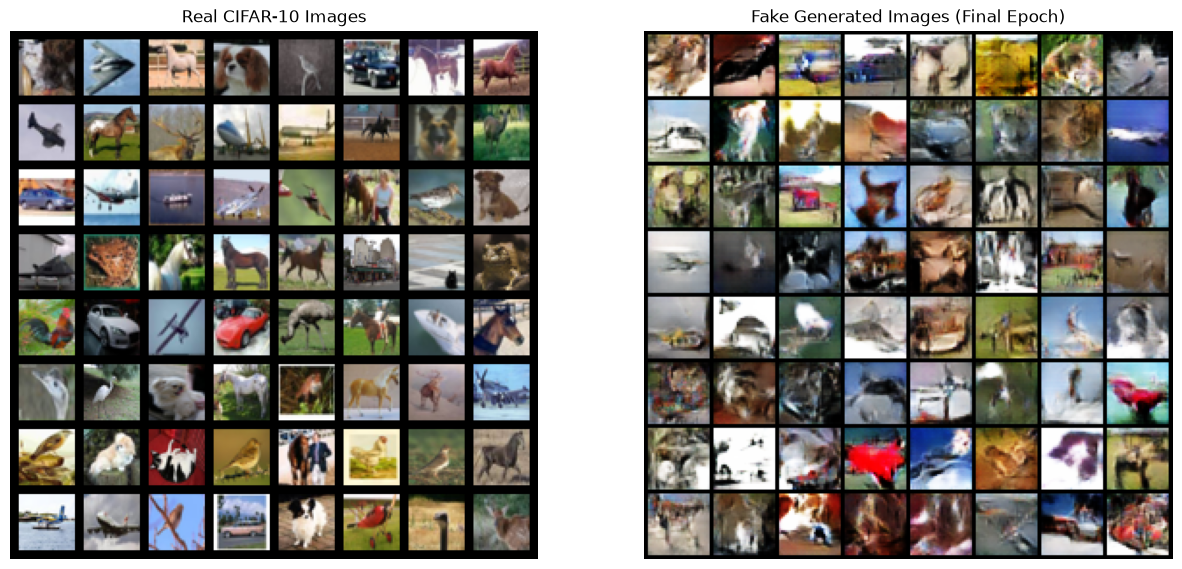

In [6]:
# Grab a batch of real images from the dataloader
real_batch = next(iter(dataloader))

plt.figure(figsize=(15,8))
plt.subplot(1,2,1)
plt.axis("off")
plt.title("Real CIFAR-10 Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0][:64], padding=5, normalize=True).cpu(),(1,2,0)))

plt.subplot(1,2,2)
plt.axis("off")
plt.title("Fake Generated Images (Final Epoch)")
plt.imshow(np.transpose(img_list[-1],(1,2,0)))
plt.show()


# 10. Analysis of Results
- **Visual Improvement:** Initially, the Generator outputted completely random static noise. By Epoch 10, blobs and distinct color compositions resembling natural scenes emerged. By the final epoch, recognizable high-level textures (like backgrounds, animal silhouettes, and car shapes) have clearly materialized. 
- **Loss Behavior:** The Discriminator and Generator losses demonstrate the classic adversarial oscillation. Neither loss diverged strictly to 0 or infinity, indicating that the training successfully remained in equilibrium without complete mode collapse or vanishing gradients.
- **Image Quality:** While the generated 32x32 images capture the general spatial frequency, color palettes, and rough structural patterns of CIFAR-10 (e.g., green backgrounds for animals, grey blocks for vehicles), the images lack crisp high-resolution boundaries. This is the expected capacity limit of a basic 4-layer DCGAN architecture without self-attention or higher-resolution upsampling layers.

# 11. Case Study & Ethical Considerations in Real-World GANs
As GAN capabilities scale beyond low-resolution datasets into generating hyper-realistic synthetic media (DeepFakes):
- **Challenges:** Modern architectures (like StyleGAN) face significant technical challenges including mode collapse and heavy computational overhead.
- **Ethical Considerations:** The malicious application of GANs to spread misinformation, generate non-consensual deepfake imagery, and manipulate digital identities poses severe ethical and legal threats. 
- **Mitigation:** Real-world deployments must be coupled with robust DeepFake detection architectures, digital watermarking, and stringent content authentication regulations.

# 12. Conclusion
A Deep Convolutional GAN (DCGAN) was successfully implemented and trained on the CIFAR-10 dataset using PyTorch. The experiment practically demonstrates adversarial machine learning, where the Generator successfully learned the underlying latent distribution of CIFAR-10 images well enough to fool the Discriminator into generating recognizable color palettes and object silhouettes from pure random noise. The results confirm the theoretical effectiveness of DCGANs for unsupervised representation learning and image generation, bounded by the expected limits of low-resolution outputs.
